In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df_raw = pd.read_csv('financial_regression.csv', parse_dates=['date']).sort_values("date")

In [3]:
gdp_dates = df_raw[df_raw["GDP"].notna()][["date","GDP"]]
print(f"GDP has {len(gdp_dates)} non-null entries. First 10:")
print(gdp_dates.head(10))

GDP has 57 non-null entries. First 10:
          date        GDP
55  2010-04-01  14980.193
121 2010-07-01  15141.607
188 2010-10-01  15309.474
254 2011-01-01  15351.448
319 2011-04-01  15557.539
385 2011-07-01  15647.680
451 2011-10-01  15842.259
517 2012-01-01  16068.805
583 2012-04-01  16207.115
649 2012-07-01  16319.541


In [4]:
gdp_dates["days_gap"] = gdp_dates["date"].diff().dt.days
print("\nGap between GDP observations (days):")
print(gdp_dates["days_gap"].describe())


Gap between GDP observations (days):
count    56.000000
mean     91.321429
std       0.765320
min      90.000000
25%      91.000000
50%      91.500000
75%      92.000000
max      92.000000
Name: days_gap, dtype: float64


as we can see the gaps are consistent (around 91 days) this tell us the data is given qurterly and there is not meaningful gaps

In [5]:
for col in ["CPI", "us_rates_%"]:
    obs = df_raw[df_raw[col].notna()][["date", col]]
    obs = obs.copy()
    obs["days_gap"] = obs["date"].diff().dt.days
    print(f"\n--- {col}: {len(obs)} observations ---")
    print(obs.head(10))
    print(obs["days_gap"].describe())


--- CPI: 176 observations ---
          date      CPI  days_gap
12  2010-02-01  217.281       NaN
32  2010-03-01  217.353      28.0
55  2010-04-01  217.403      31.0
77  2010-05-01  217.290      30.0
99  2010-06-01  217.199      31.0
121 2010-07-01  217.605      30.0
143 2010-08-01  217.923      31.0
166 2010-09-01  218.275      31.0
188 2010-10-01  219.035      30.0
209 2010-11-01  219.590      31.0
count    175.000000
mean      30.434286
std        0.819988
min       28.000000
25%       30.000000
50%       31.000000
75%       31.000000
max       31.000000
Name: days_gap, dtype: float64

--- us_rates_%: 176 observations ---
          date  us_rates_%  days_gap
12  2010-02-01        0.13       NaN
32  2010-03-01        0.16      28.0
55  2010-04-01        0.20      31.0
77  2010-05-01        0.20      30.0
99  2010-06-01        0.18      31.0
121 2010-07-01        0.18      30.0
143 2010-08-01        0.19      31.0
166 2010-09-01        0.19      31.0
188 2010-10-01        0.19      3

for the CPI and the us rates we see the gaps are also consistent of around 31 days, so the data is given monthly

/Users/alvaroresano/Desktop/cuarto/AdvML/advml_venv/lib/python3.10/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
/Users/alvaroresano/Desktop/cuarto/AdvML/advml_venv/lib/python3.10/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
/Users/alvaroresano/Desktop/cuarto/AdvML/advml_venv/lib/python3.10/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


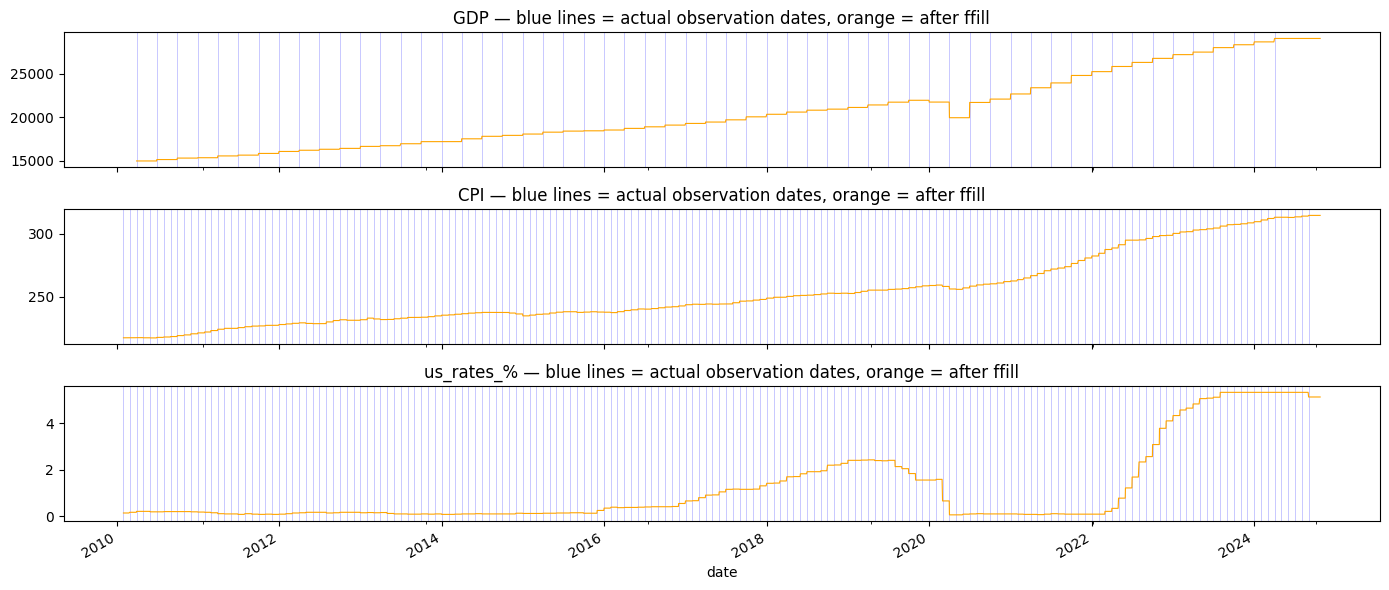

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
for ax, col in zip(axes, ["GDP", "CPI", "us_rates_%"]):
    obs_dates = df_raw[df_raw[col].notna()]["date"]
    # Mark the actual publication dates as vertical lines
    for d in obs_dates:
        ax.axvline(d, alpha=0.3, color="blue", linewidth=0.5)
    df_raw.set_index("date")[col].ffill().plot(ax=ax, color="orange", linewidth=0.8)
    ax.set_title(f"{col} — blue lines = actual observation dates, orange = after ffill")
plt.tight_layout()
plt.show()

In [7]:
# After your existing ffill (Cell 5), check if any macro columns still have NaNs
df_filled = pd.read_csv("financial_regression.csv", parse_dates=["date"]).sort_values("date")
df_filled = df_filled[df_filled["date"] >= "2010-04-01"].reset_index(drop=True)
df_filled[["GDP","CPI","us_rates_%"]] = df_filled[["GDP","CPI","us_rates_%"]].ffill()

still_null = df_filled[["GDP","CPI","us_rates_%"]].isnull().sum()
print("NaNs remaining after ffill:", still_null)

# If any remain, they are at the BEGINNING — show them
print(df_filled[["date","GDP","CPI","us_rates_%"]].head(20))

NaNs remaining after ffill: GDP           0
CPI           0
us_rates_%    0
dtype: int64
         date        GDP      CPI  us_rates_%
0  2010-04-01  14980.193  217.403         0.2
1  2010-04-02  14980.193  217.403         0.2
2  2010-04-05  14980.193  217.403         0.2
3  2010-04-06  14980.193  217.403         0.2
4  2010-04-07  14980.193  217.403         0.2
5  2010-04-08  14980.193  217.403         0.2
6  2010-04-09  14980.193  217.403         0.2
7  2010-04-12  14980.193  217.403         0.2
8  2010-04-13  14980.193  217.403         0.2
9  2010-04-14  14980.193  217.403         0.2
10 2010-04-15  14980.193  217.403         0.2
11 2010-04-16  14980.193  217.403         0.2
12 2010-04-19  14980.193  217.403         0.2
13 2010-04-20  14980.193  217.403         0.2
14 2010-04-21  14980.193  217.403         0.2
15 2010-04-22  14980.193  217.403         0.2
16 2010-04-23  14980.193  217.403         0.2
17 2010-04-26  14980.193  217.403         0.2
18 2010-04-27  14980.193  217.403    

In [8]:
print(df_filled.dtypes.value_counts())
print("\n--- Null counts ---")
null_summary = df_filled.isnull().sum().sort_values(ascending=False)
null_pct = (null_summary / len(df_filled) * 100).round(2)
pd.concat([null_summary, null_pct], axis=1, keys=["nulls", "%"]).query("nulls > 0")

float64           46
datetime64[ns]     1
Name: count, dtype: int64

--- Null counts ---


,nulls,%
eur_usd,208,5.40
usd_chf,208,5.40
silver high-low,183,4.75
oil high,183,4.75
oil close,183,4.75
oil volume,183,4.75
oil high-low,183,4.75
platinum open,183,4.75
platinum high,183,4.75
platinum low,183,4.75


In [9]:
df_descp = df_filled.describe(include='number').T.sort_values("mean", ascending=False)

In [10]:
df_descp['max/min ratio'] = df_descp['max'] / df_descp['min']

In [11]:
df_descp.head(10)

,count,mean,std,min,25%,50%,75%,max,max/min ratio
sp500 volume,3666.0,1.110980e+08,6.800023e+07,2.027001e+07,6.662305e+07,9.166868e+07,1.350369e+08,7.095045e+08,35.002674
nasdaq volume,3666.0,4.455753e+07,2.498151e+07,7.079300e+06,2.707837e+07,3.865842e+07,5.534791e+07,2.882004e+08,40.710296
oil volume,3666.0,1.634754e+07,3.059537e+07,7.346540e+05,4.597531e+06,9.167944e+06,2.128463e+07,9.989044e+08,1359.693687
gold volume,3666.0,9.555176e+06,6.126566e+06,1.436508e+06,5.768047e+06,8.000212e+06,1.141523e+07,9.369811e+07,65.226304
silver volume,3666.0,3.894066e+05,4.994607e+05,1.494100e+04,9.494475e+04,2.138865e+05,5.103358e+05,7.374159e+06,493.551904
platinum volume,3666.0,8.883756e+04,8.387258e+04,4.833000e+03,3.559325e+04,6.371900e+04,1.119425e+05,1.173733e+06,242.858059
palladium volume,3666.0,6.963373e+04,9.547047e+04,3.157000e+03,2.068175e+04,3.777900e+04,8.155175e+04,1.199042e+06,379.804245
GDP,3849.0,2.052073e+04,4.123190e+03,1.498019e+04,1.719202e+04,1.969260e+04,2.265679e+04,2.901671e+04,1.937005
sp500 high,3666.0,2.724529e+02,1.214189e+02,1.034200e+02,1.784600e+02,2.443650e+02,3.802550e+02,5.861200e+02,5.667376
sp500 close,3666.0,2.710413e+02,1.207900e+02,1.022000e+02,1.776125e+02,2.433850e+02,3.773550e+02,5.845900e+02,5.720059


As we can see the data is not inconsistent or bad data, there is no 0 or negative min values for prices, the ratio between the max/min is not somenthing crazy but in line with the asset or index 

In [12]:
change_freq = {}
for col in df_filled.columns:
    if col == "date":
        continue
    changes = df_filled[col].diff().ne(0).sum()
    change_freq[col] = changes

freq_df = pd.Series(change_freq).sort_values()
print(freq_df)

GDP                     57
us_rates_%             119
CPI                    173
silver open           3786
silver close          3802
silver high           3811
silver low            3812
oil open              3814
silver high-low       3815
usd_chf               3817
eur_usd               3818
oil close             3825
oil low               3825
oil high-low          3827
gold open             3830
palladium high        3831
oil high              3832
platinum open         3832
gold low              3834
sp500 open            3835
platinum close        3836
nasdaq open           3836
platinum low          3836
nasdaq close          3837
gold high             3837
gold close            3838
nasdaq high           3838
sp500 close           3838
palladium open        3838
sp500 high-low        3839
nasdaq high-low       3839
palladium close       3840
nasdaq low            3841
sp500 high            3841
palladium low         3843
platinum high         3843
sp500 low             3843
p

here we can see the change of each column and the patterns are correct with what we now about the asset or index, the OHLCV columns has daily changes (around 3840) and for the GDP quarterly (57 changes)

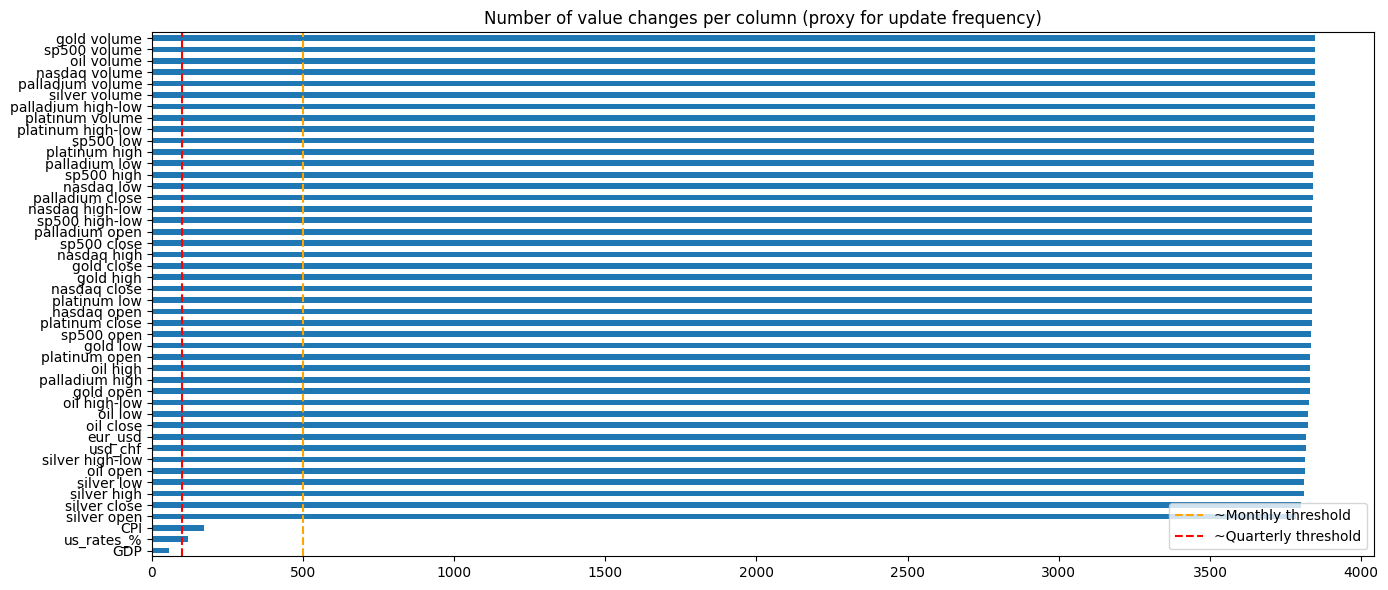

In [13]:
fig, ax = plt.subplots(figsize=(14, 6))
freq_df.plot(kind='barh', ax=ax)
ax.axvline(x=500, color='orange', linestyle='--', label='~Monthly threshold')
ax.axvline(x=100, color='red', linestyle='--', label='~Quarterly threshold')
ax.set_title("Number of value changes per column (proxy for update frequency)")
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
close_cols = [c for c in df_filled.columns if "close" in c.lower()]
print(close_cols)

['sp500 close', 'nasdaq close', 'silver close', 'oil close', 'platinum close', 'palladium close', 'gold close']


## Distribution & Outlier Analysis

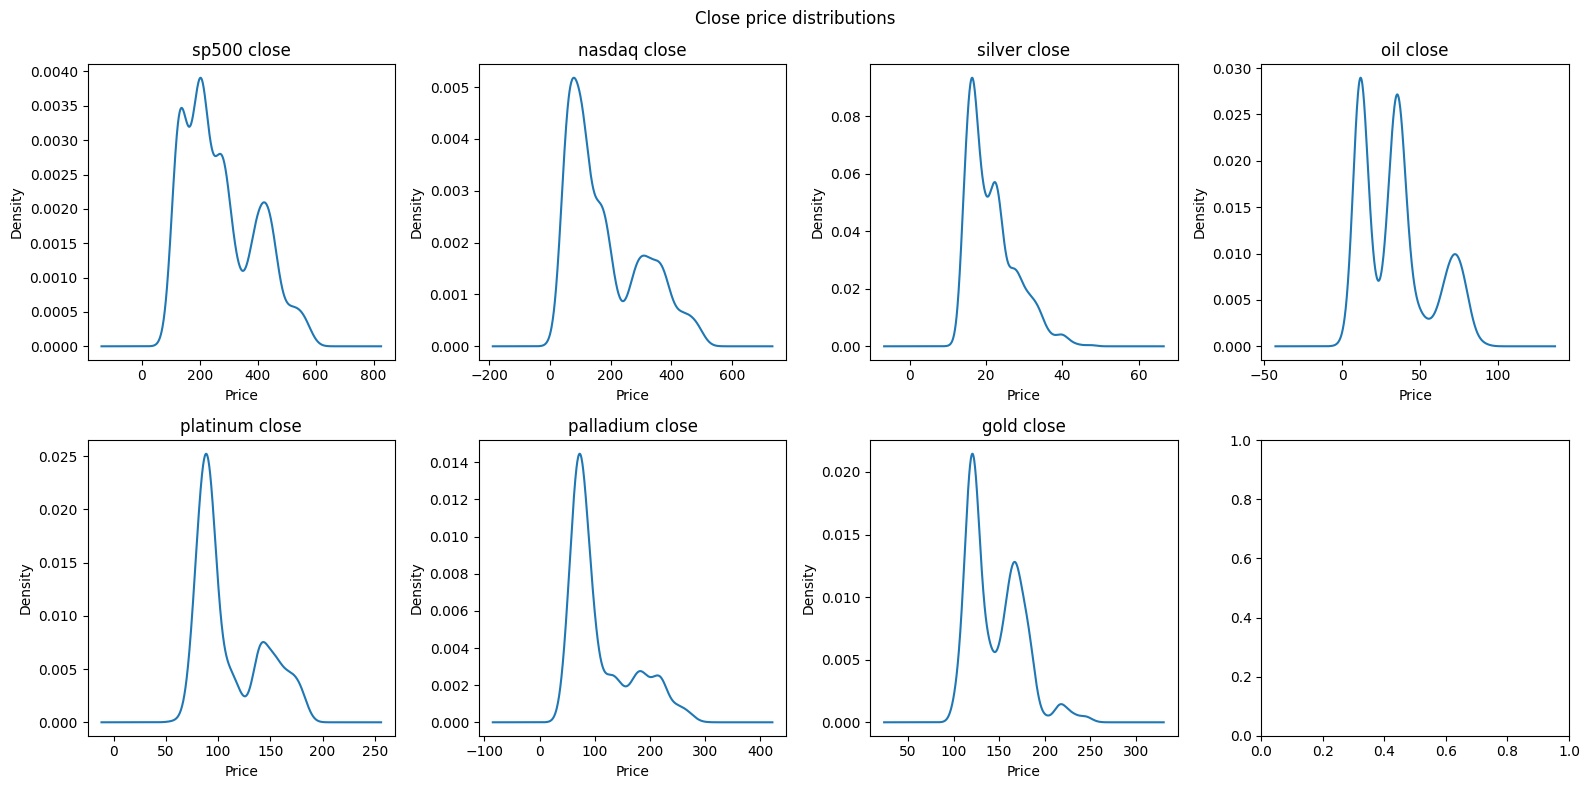

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, close_cols):
    df_filled[col].dropna().plot(kind='kde', ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Price")
plt.suptitle("Close price distributions")
plt.tight_layout()
plt.show()

/var/folders/cx/247z29v95p7c3srnc7p2r60h0000gp/T/ipykernel_6712/3790537299.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  log_returns = df_filled[close_cols].pct_change().apply(np.log1p)


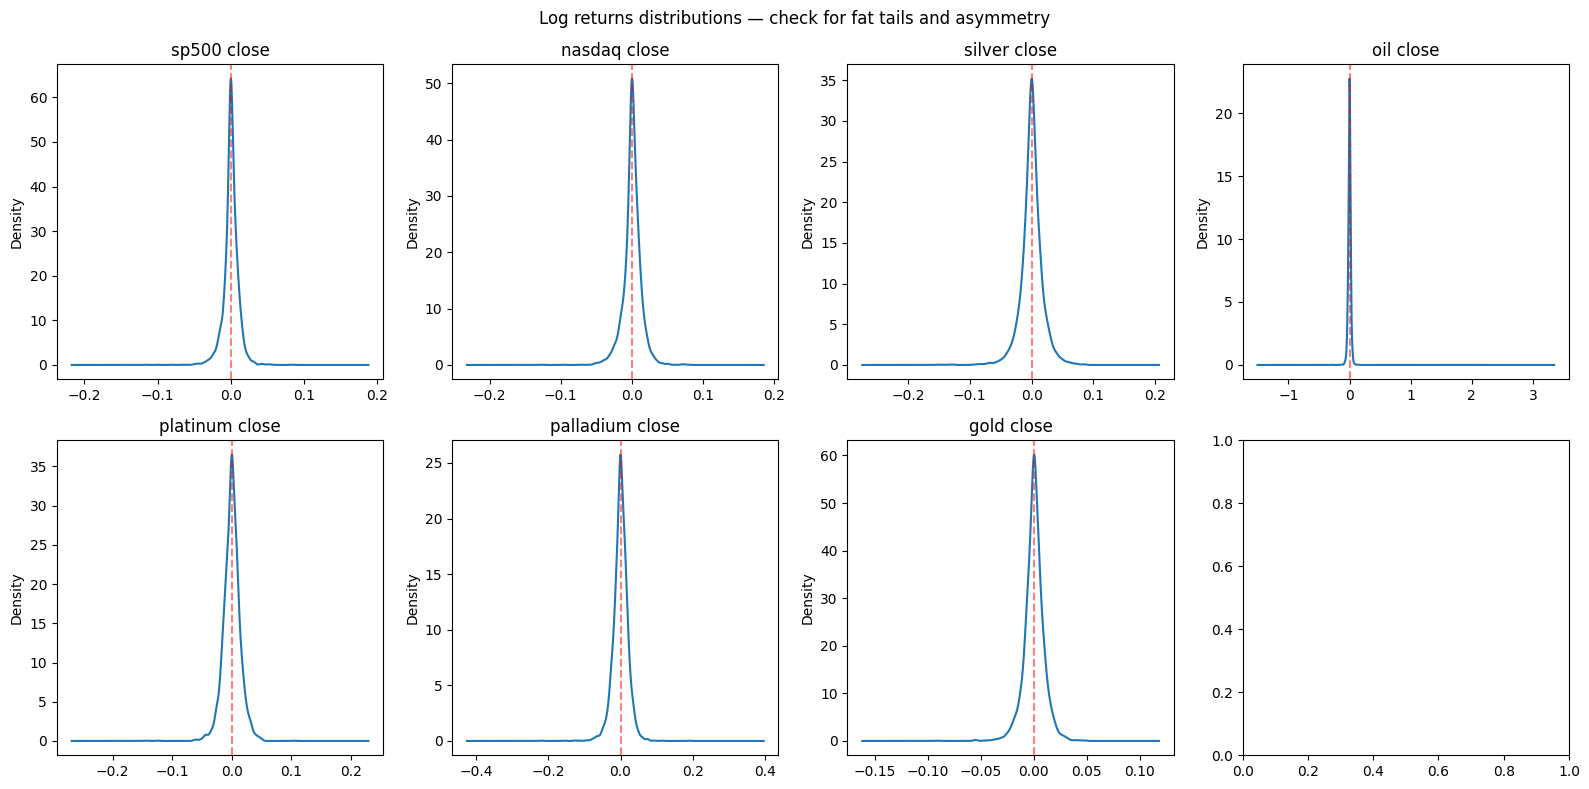

In [16]:
log_returns = df_filled[close_cols].pct_change().apply(np.log1p)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, log_returns.columns):
    log_returns[col].dropna().plot(kind='kde', ax=ax)
    ax.axvline(0, color='red', linestyle='--', alpha=0.5)
    ax.set_title(col)
plt.suptitle("Log returns distributions — check for fat tails and asymmetry")
plt.tight_layout()
plt.show()

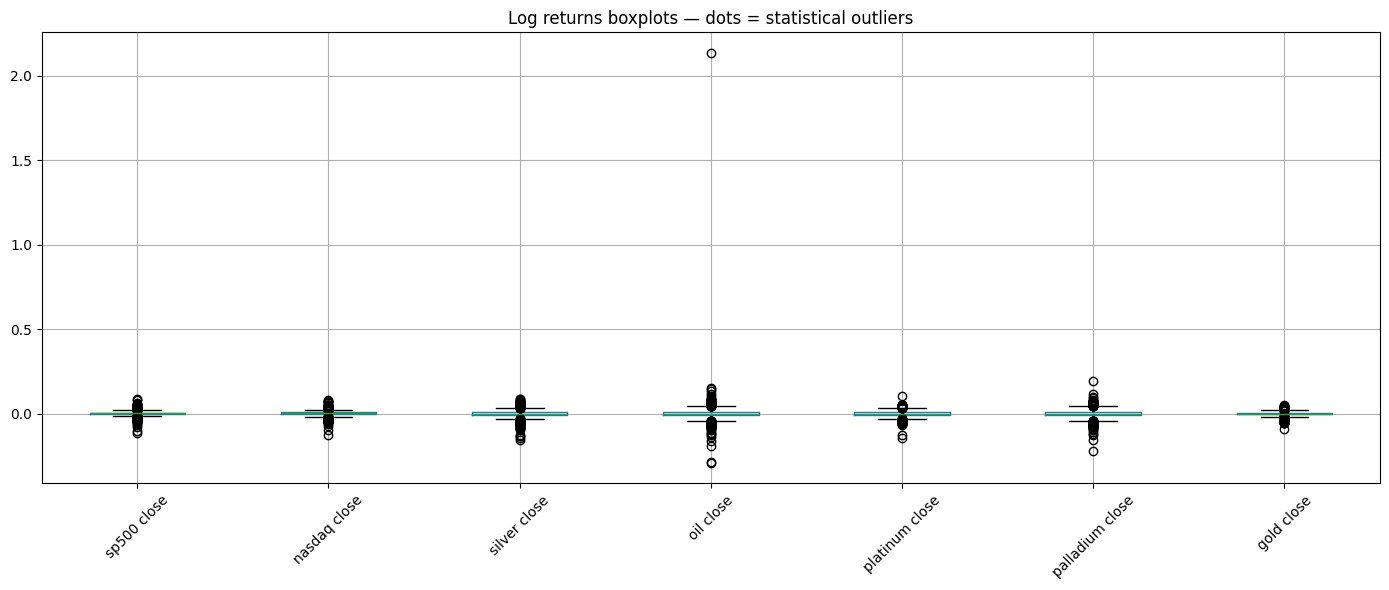

In [17]:
fig, ax = plt.subplots(figsize=(14, 6))
log_returns.boxplot(ax=ax, rot=45)
ax.set_title("Log returns boxplots — dots = statistical outliers")
plt.tight_layout()
plt.show()

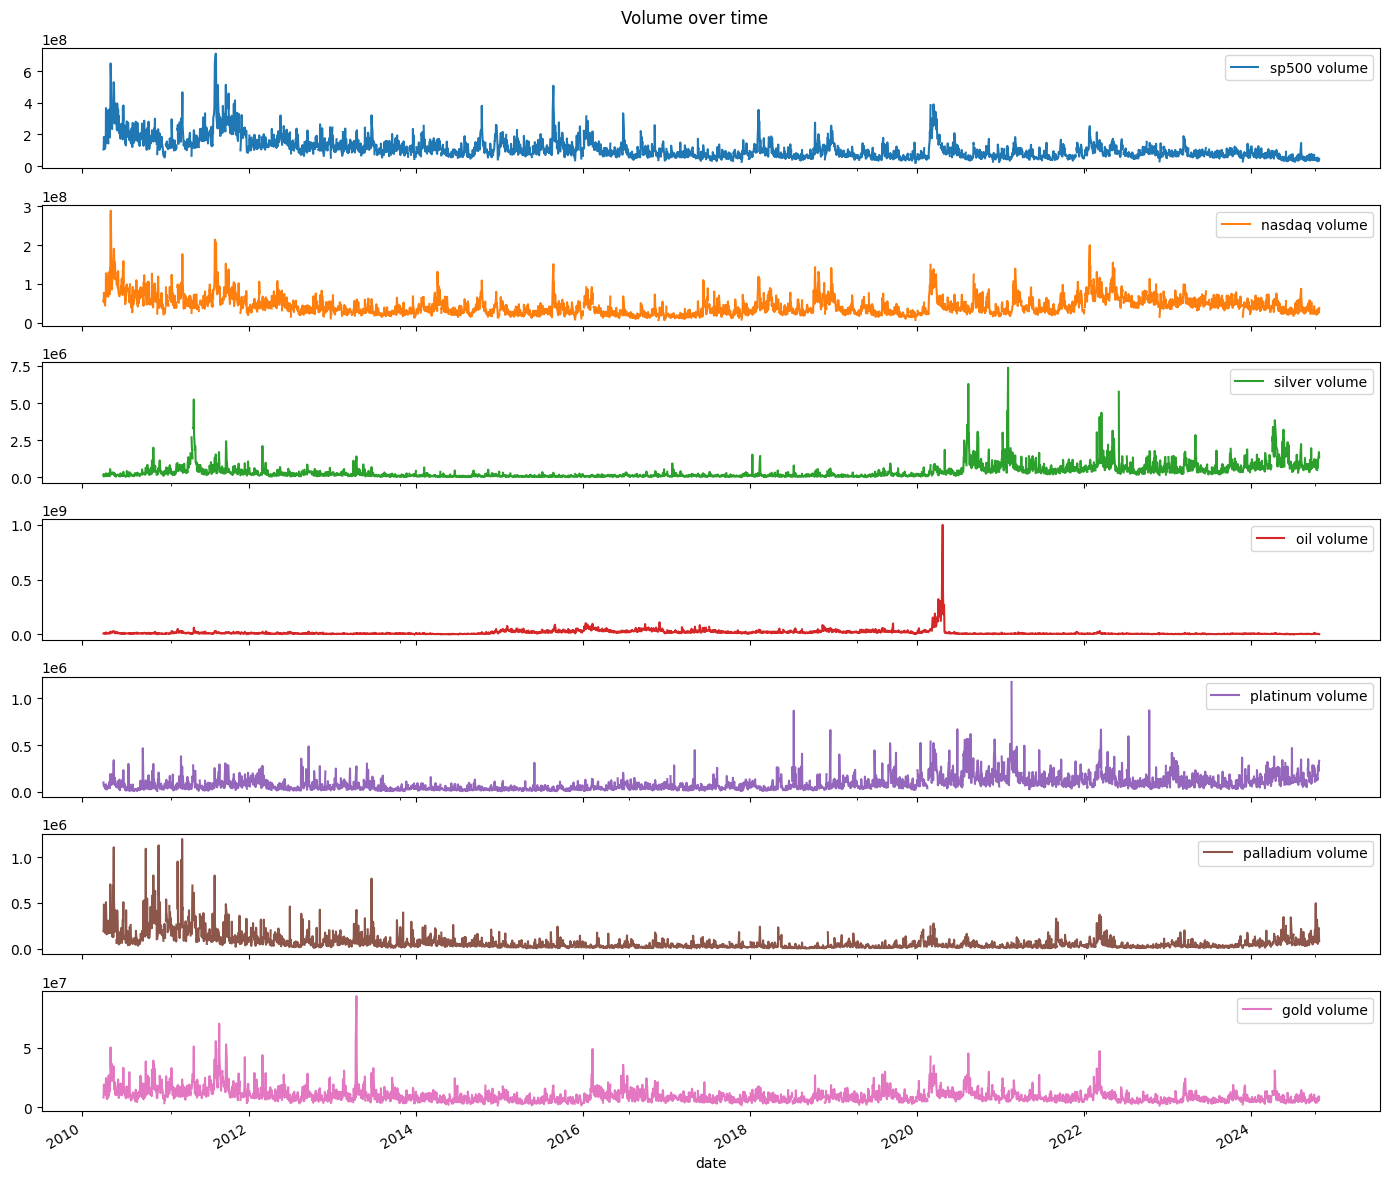

In [18]:
vol_cols = [c for c in df_filled.columns if "volume" in c.lower()]
df_filled[["date"] + vol_cols].set_index("date").plot(subplots=True, figsize=(14, 12), title="Volume over time")
plt.tight_layout()
plt.show()

Price comparison (we need to normalize the prices)

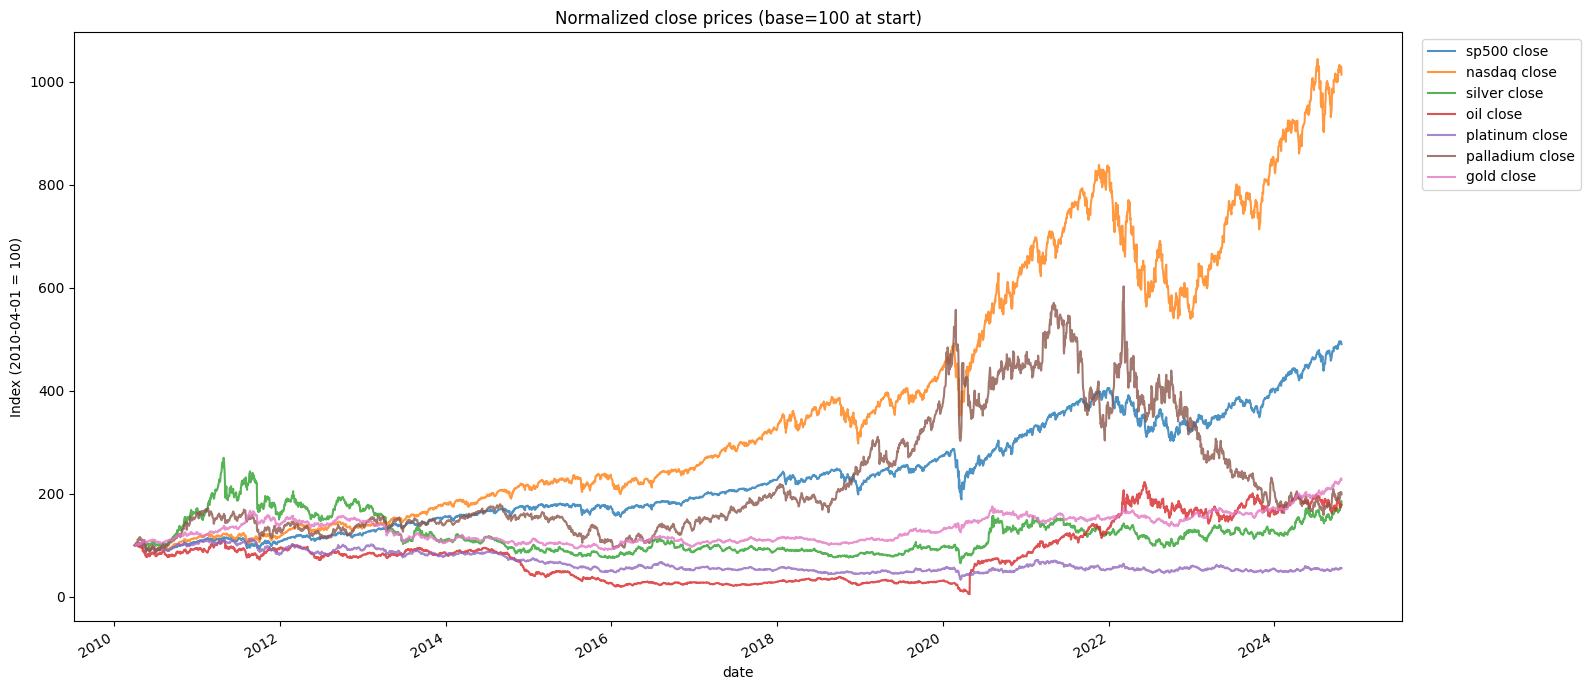

In [19]:
close_data = df_filled.set_index("date")[close_cols].dropna(how="all")
normalized = close_data.div(close_data.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(16, 7))
normalized.plot(ax=ax, alpha=0.8)
ax.set_title("Normalized close prices (base=100 at start)")
ax.set_ylabel("Index (2010-04-01 = 100)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

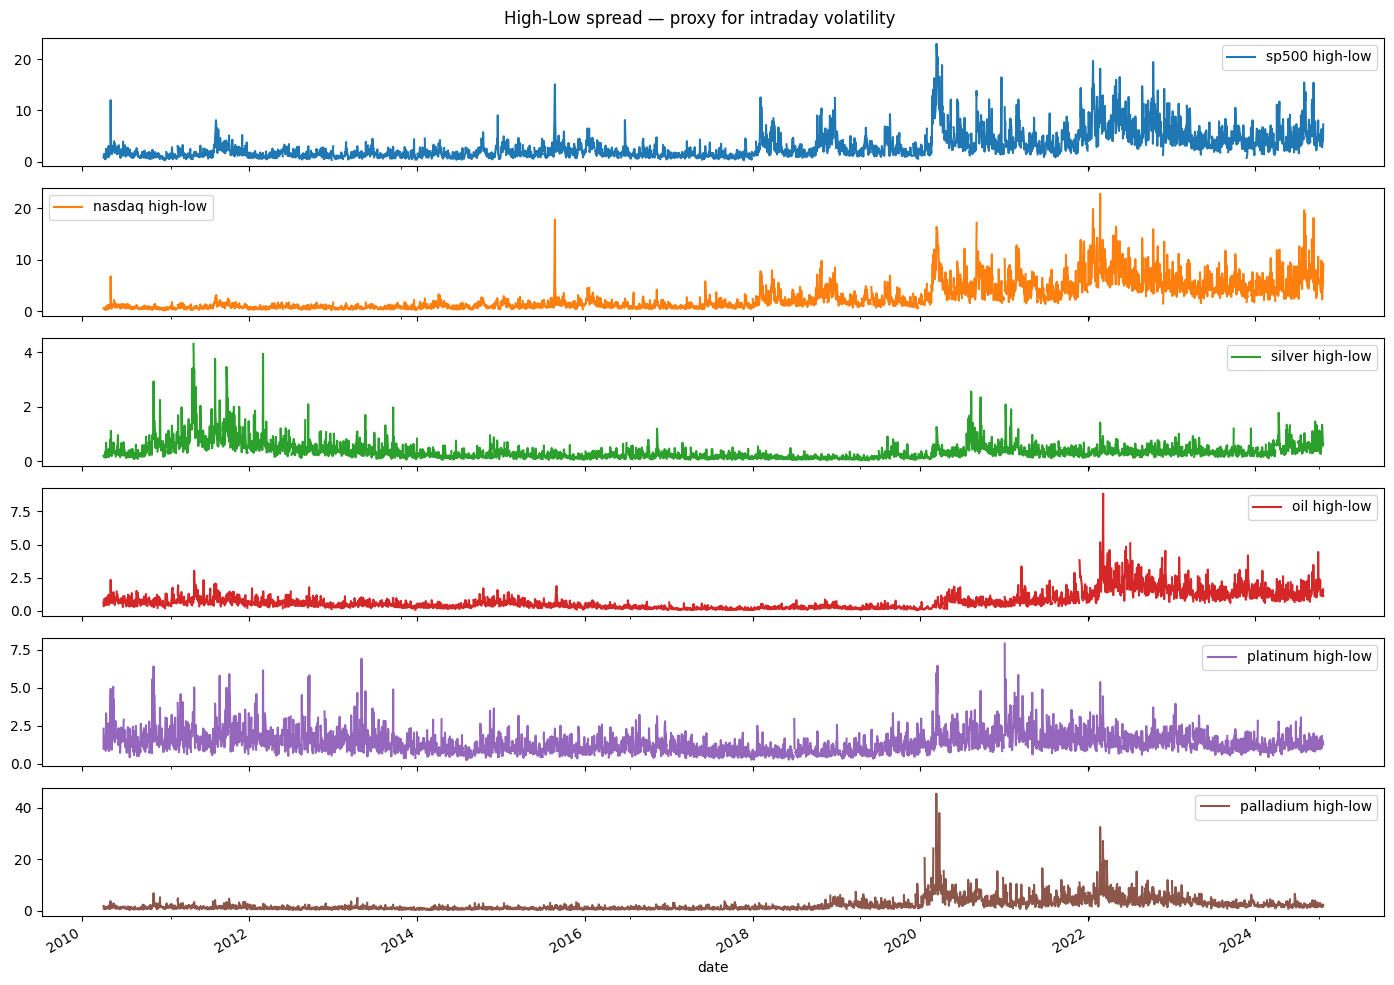

In [20]:
hl_cols = [c for c in df_filled.columns if "high-low" in c.lower() or "hl" in c.lower()]
if hl_cols:
    df_filled.set_index("date")[hl_cols].plot(subplots=True, figsize=(14, 10))
    plt.suptitle("High-Low spread — proxy for intraday volatility")
    plt.tight_layout()
    plt.show()

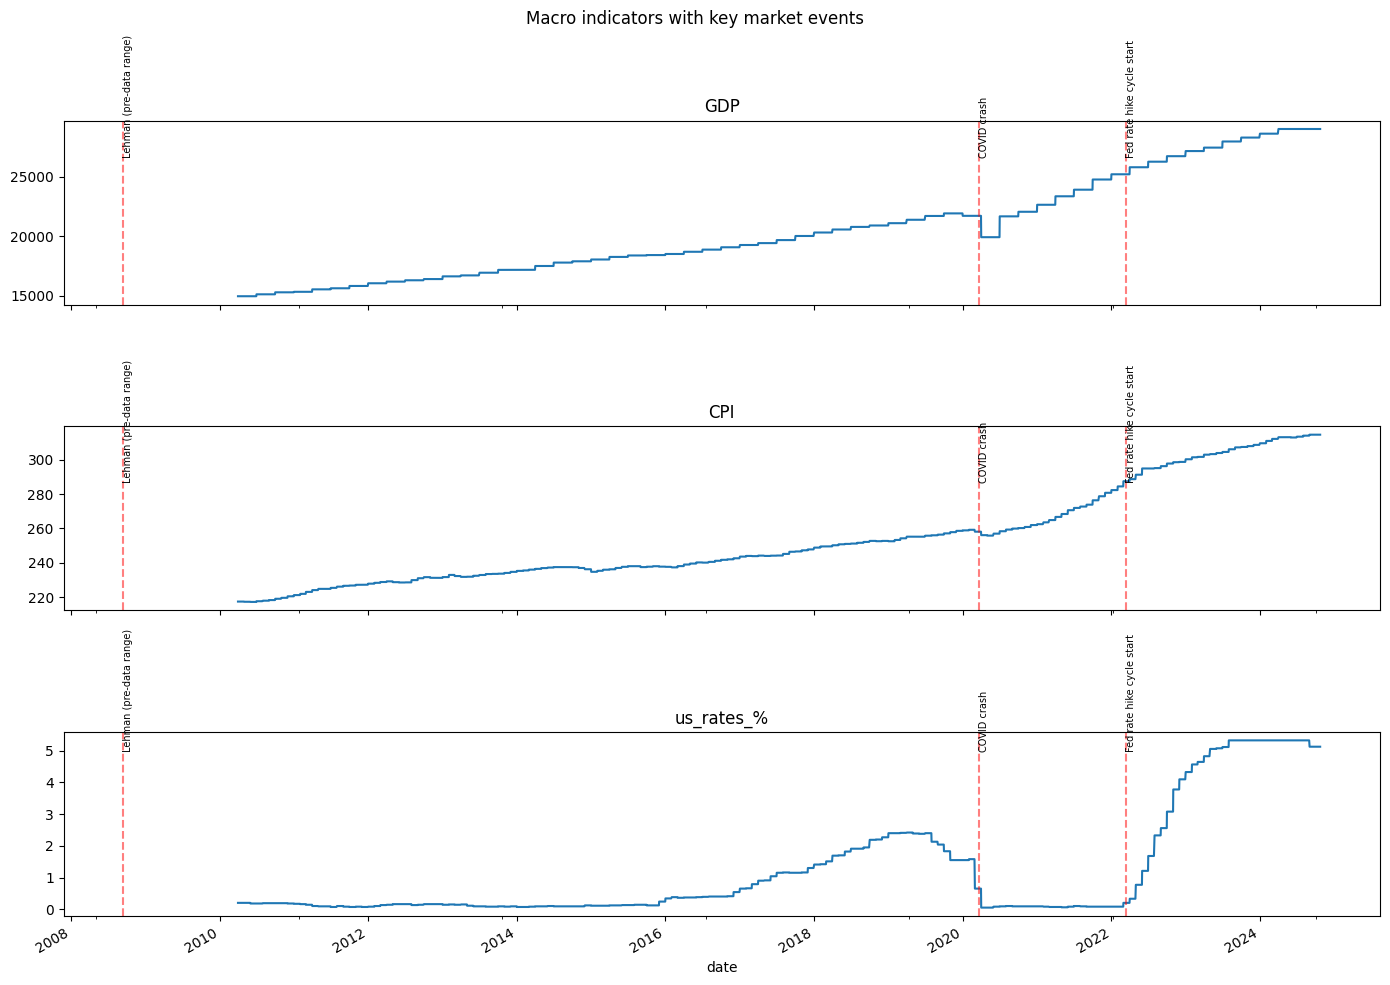

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
events = {
    "2020-03-20": "COVID crash",
    "2022-03-16": "Fed rate hike cycle start",
    "2008-09-15": "Lehman (pre-data range)"
}
for ax, col in zip(axes, ["GDP", "CPI", "us_rates_%"]):
    df_filled.set_index("date")[col].plot(ax=ax)
    ax.set_title(col)
    for date, label in events.items():
        try:
            ax.axvline(pd.Timestamp(date), color="red", alpha=0.5, linestyle="--")
            ax.text(pd.Timestamp(date), ax.get_ylim()[1]*0.9, label, fontsize=7, rotation=90)
        except:
            pass
plt.suptitle("Macro indicators with key market events")
plt.tight_layout()
plt.show()

## Correlation Analysis

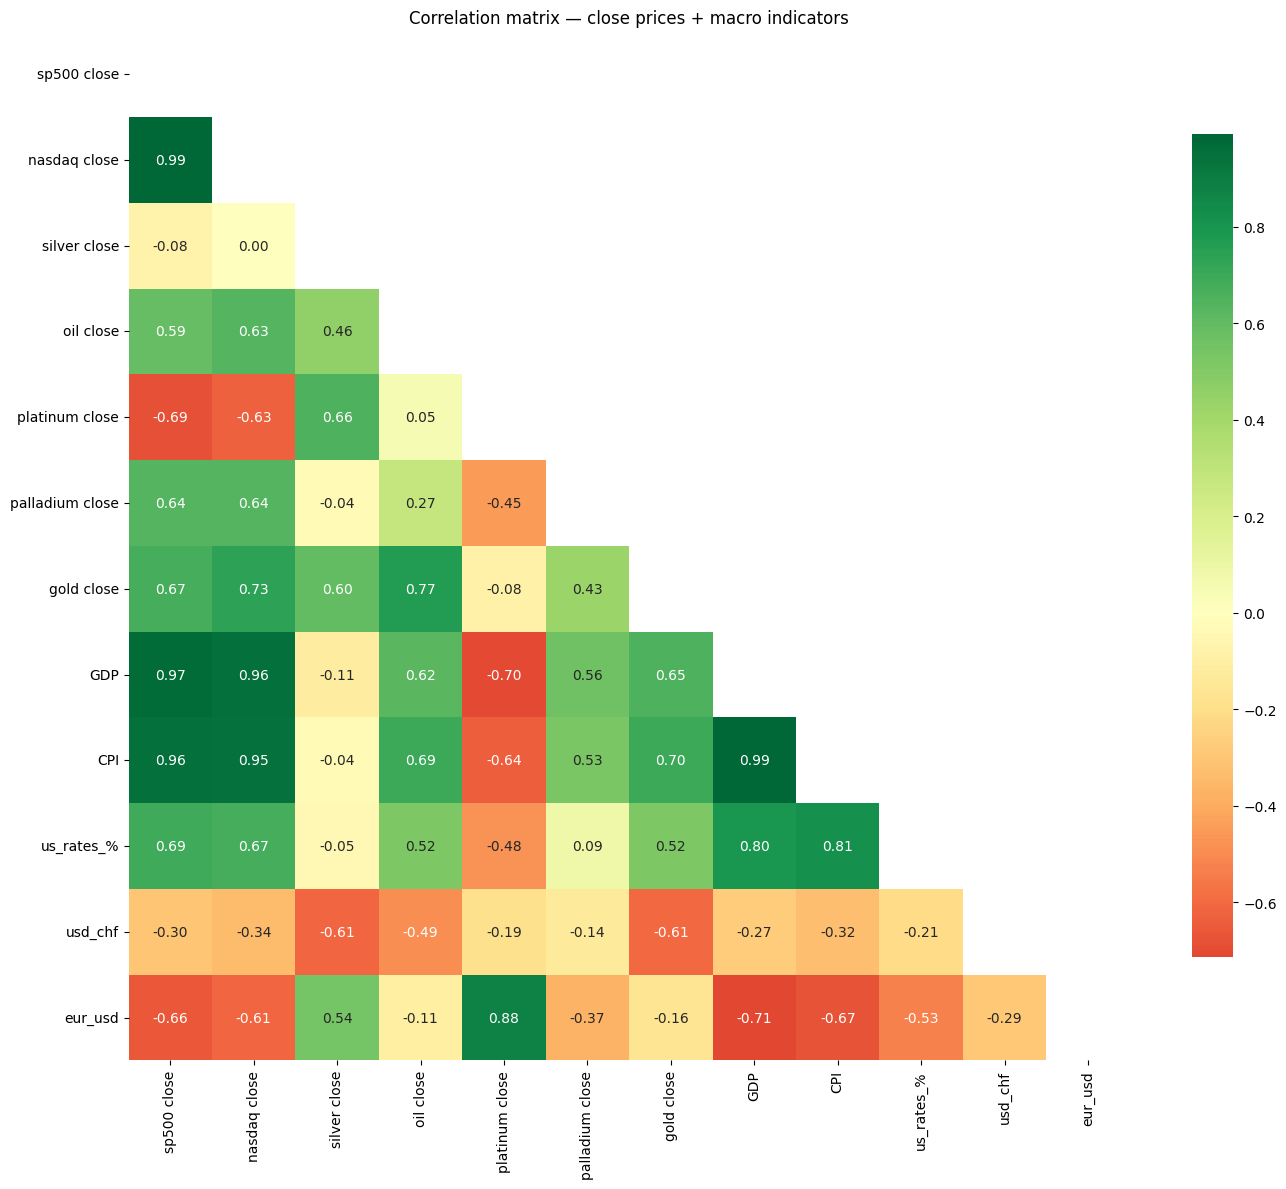

In [22]:
analysis_cols = close_cols + ["GDP", "CPI", "us_rates_%", "usd_chf", "eur_usd"]
corr = df_filled[analysis_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation matrix — close prices + macro indicators")
plt.tight_layout()
plt.show()